In [1]:
# STEP 0: Install Libraries
# ==============================
!pip install yfinance arch statsmodels


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.4 MB/s eta 0:00:00


In [2]:
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.stats.diagnostic import het_arch
from arch import arch_model


In [3]:
# STEP 2: Download REAL Data
# ==============================
df = yf.download("^NSEI", start="2015-01-01", end="2025-01-01")

# Keep only closing price
df = df[['Close']]


/tmp/ipykernel_22786/4228412083.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^NSEI", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [4]:
# STEP 3: Compute Log Returns
# ==============================
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop missing values
df = df.dropna()

print("Total observations:", len(df))
df.head()

Total observations: 2458


Price,Close,Log_Return
Ticker,^NSEI,
Date,,
2015-01-05,8378.400391,-0.002033
2015-01-06,8127.350098,-0.030422
2015-01-07,8102.100098,-0.003112
2015-01-08,8234.599609,0.016221
2015-01-09,8284.500000,0.006042


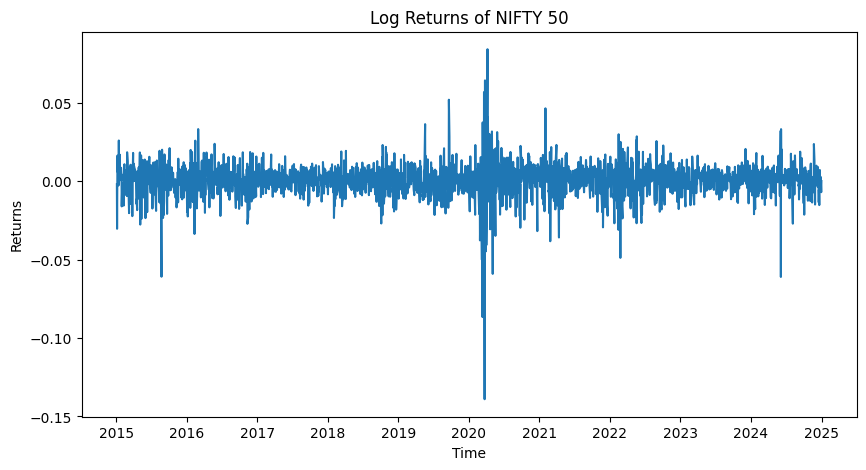

In [5]:
# STEP 4: Plot Returns
# ==============================
plt.figure(figsize=(10,5))
plt.plot(df['Log_Return'])
plt.title("Log Returns of NIFTY 50")
plt.xlabel("Time")
plt.ylabel("Returns")
plt.show()


In [6]:
# STEP 5: ARCH LM Test
# ==============================
arch_test = het_arch(df['Log_Return'])

print("\n===== ARCH LM TEST =====")
print("Test Statistic:", arch_test[0])
print("p-value:", arch_test[1])

if arch_test[1] < 0.05:
    print("Conclusion: ARCH effect present ✅")
else:
    print("Conclusion: No ARCH effect ❌")


===== ARCH LM TEST =====
Test Statistic: 639.0450767515309
p-value: 7.522691655118753e-131
Conclusion: ARCH effect present ✅


In [7]:
# STEP 6: ARCH Model
# ==============================
arch_model_fit = arch_model(df['Log_Return'], vol='ARCH', p=1).fit()

print("\n===== ARCH MODEL SUMMARY =====")
print(arch_model_fit.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 8.69525648632183e+20
Iteration:      2,   Func. Count:     17,   Neg. LLF: 52442635439212.65
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7925.181339699193
            Iterations: 2
            Function evaluations: 24
            Gradient evaluations: 2

===== ARCH MODEL SUMMARY =====
                      Constant Mean - ARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                7925.18
Distribution:                  Normal   AIC:                          -15844.4
Method:            Maximum Likelihood   BIC:                          -15826.9
                                        No. Observations:                 2458
Date:                Thu, Apr 02 2026   Df Residuals:       

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001111. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [8]:
# STEP 7: GARCH Model (MAIN)
# ==============================
garch_model_fit = arch_model(df['Log_Return'], vol='GARCH', p=1, q=1).fit()

print("\n===== GARCH MODEL SUMMARY =====")
print(garch_model_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 2331729513615.1455
Iteration:      2,   Func. Count:     19,   Neg. LLF: 77154.02137850175
Iteration:      3,   Func. Count:     29,   Neg. LLF: 1.9802019928203354e+18
Iteration:      4,   Func. Count:     42,   Neg. LLF: 8031410.5148069905
Optimization terminated successfully    (Exit mode 0)
            Current function value: -8125.660727860315
            Iterations: 5
            Function evaluations: 49
            Gradient evaluations: 4

===== GARCH MODEL SUMMARY =====
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                8125.66
Distribution:                  Normal   AIC:                          -16243.3
Method:            Maximum Likelihood   BIC:                         

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001111. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [9]:
# STEP 8: Model Comparison
# ==============================
print("\n===== MODEL COMPARISON =====")
print("ARCH AIC:", arch_model_fit.aic)
print("GARCH AIC:", garch_model_fit.aic)

print("ARCH BIC:", arch_model_fit.bic)
print("GARCH BIC:", garch_model_fit.bic)


===== MODEL COMPARISON =====
ARCH AIC: -15844.362679398386
GARCH AIC: -16243.32145572063
ARCH BIC: -15826.941369528007
GARCH BIC: -16220.093042560125


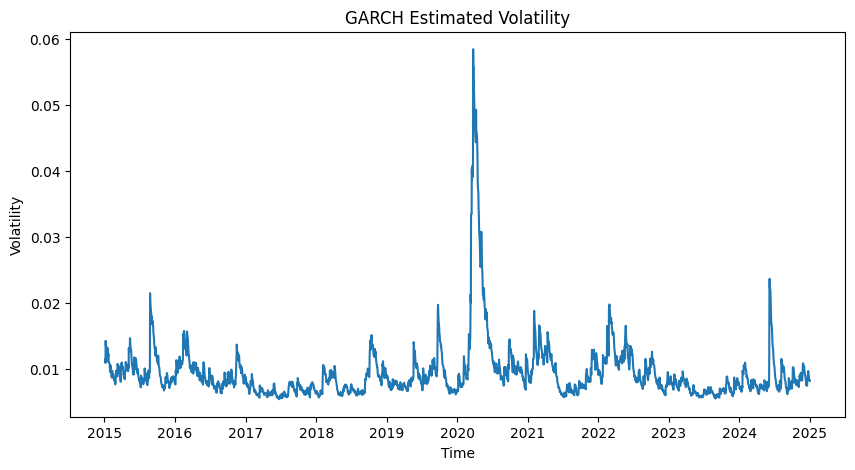

In [10]:
# STEP 9: Plot Volatility
# ==============================
plt.figure(figsize=(10,5))
plt.plot(garch_model_fit.conditional_volatility)
plt.title("GARCH Estimated Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

In [11]:
# STEP 10: Save Final Dataset
# ==============================
df.to_csv("NIFTY_50_final_dataset.csv")

print("\nDataset saved as NIFTY_50_final_dataset.csv")


Dataset saved as NIFTY_50_final_dataset.csv
